### Exploring all  the different csv fies in the data folder

In [12]:
import pandas as pd
import numpy as np
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### Question: How does the data look? What are the fields?

In [ ]:

data_folder="data/Welltory hrv-covid19 master data"
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)
        print(f"--- {filename} ---")
        print(df.head())
    

--- blood_pressure.csv ---
    user_code  measurement_datetime  diastolic  systolic  \
0  01bad5a519  2020-04-29  22:33:33        100       150   
1  01bad5a519  2020-04-30  01:33:33        100       150   
2  01bad5a519  2020-04-30  09:16:38         95       140   
3  01bad5a519  2020-04-30  12:16:38         95       140   
4  01bad5a519  2020-05-01  06:58:06         80       130   

   functional_changes_index  circulatory_efficiency  kerdo_vegetation_index  \
0                       NaN                     NaN                     NaN   
1                       NaN                     NaN                     NaN   
2                      3.38                  4545.0                     6.0   
3                       NaN                     NaN                     NaN   
4                      2.89                  4000.0                     NaN   

   robinson_index  
0             NaN  
1             NaN  
2           141.4  
3             NaN  
4           104.0  
--- heart_rate.cs

### From inspection, I see some missing values in the different datasets
### How many missing values are in each column for each dataset 

In [8]:
#Checking for missing values in each dataset
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)
        print(f"--- {filename} ---")
        print(df.isnull().sum())

--- blood_pressure.csv ---
user_code                     0
measurement_datetime          0
diastolic                     0
systolic                      0
functional_changes_index    422
circulatory_efficiency      422
kerdo_vegetation_index      438
robinson_index              422
dtype: int64
--- heart_rate.csv ---
user_code     0
datetime      0
heart_rate    0
is_resting    0
dtype: int64
--- hrv_measurements.csv ---
user_code                  0
rr_code                    0
measurement_datetime       0
time_of_day                0
bpm                        0
meanrr                     0
mxdmn                      0
sdnn                       0
rmssd                      0
pnn50                      0
mode                       0
amo                        0
lf                         0
hf                         0
vlf                        0
lfhf                       0
total_power                0
how_feel                   0
how_mood                   0
how_sleep               

### Datsets without missing values are heart_rate.csv,surveys.csv and weather.csv

### What are the statistics? What information about the distribution can I get from them?

In [ ]:
#checking the distribution of the data by seeing if median values (50%) are close to mean values
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)
        print(f"--- {filename} ---")
        print(df.describe())

--- blood_pressure.csv ---
        diastolic    systolic  functional_changes_index  \
count  721.000000  721.000000                299.000000   
mean    81.228849  119.441054                  2.594013   
std      8.865761   10.522578                  0.291302   
min     25.000000   63.000000                  1.680000   
25%     76.000000  113.000000                  2.440000   
50%     82.000000  120.000000                  2.580000   
75%     88.000000  126.000000                  2.730000   
max    101.000000  157.000000                  3.510000   

       circulatory_efficiency  kerdo_vegetation_index  robinson_index  
count              299.000000              283.000000      299.000000  
mean              2735.197057              -15.498233       84.663779  
std                747.882570               18.681233       14.399208  
min               1300.000000              -76.000000       49.500000  
25%               2250.500000              -29.000000       75.580000  
50%      

### mean is close to median for most hence symmetry is assumed

### Checking for categorical inputs and separating from numeric inputs


In [15]:
#checking for categorical inputs and separating from numeric inputs
def separate_columns(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    return numeric_cols, categorical_cols

In [16]:
#Separating categorical and numerical columns for each dataset 
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)
        numeric_cols, categorical_cols = separate_columns(df)
        print(f"--- {filename} ---")
        print("Numeric columns:", numeric_cols)
        print("Categorical columns:", categorical_cols)

--- blood_pressure.csv ---
Numeric columns: ['diastolic', 'systolic', 'functional_changes_index', 'circulatory_efficiency', 'kerdo_vegetation_index', 'robinson_index']
Categorical columns: ['user_code', 'measurement_datetime']
--- heart_rate.csv ---
Numeric columns: ['heart_rate', 'is_resting']
Categorical columns: ['user_code', 'datetime']
--- hrv_measurements.csv ---
Numeric columns: ['bpm', 'meanrr', 'mxdmn', 'sdnn', 'rmssd', 'pnn50', 'mode', 'amo', 'lf', 'hf', 'vlf', 'lfhf', 'total_power', 'how_feel', 'how_mood', 'how_sleep']
Categorical columns: ['user_code', 'rr_code', 'measurement_datetime', 'time_of_day', 'tags', 'rr_data']
--- participants.csv ---
Numeric columns: ['height', 'weight']
Categorical columns: ['user_code', 'gender', 'age_range', 'city', 'country', 'symptoms_onset']
--- scales_description.csv ---
Numeric columns: ['Value']
Categorical columns: ['Scale', 'Description', 'Meaning']
--- sleep.csv ---
Numeric columns: ['sleep_duration', 'sleep_awake_duration', 'sleep_re

### Checking for skewness (is assumption right?)

In [17]:
#checking for skewness of the numerical 
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)
        numeric_cols, categorical_cols = separate_columns(df)
        print(f"--- {filename} ---")
        for col in numeric_cols:
            skewness = df[col].skew()
            print(f"Skewness of {col}: {skewness}")

--- blood_pressure.csv ---
Skewness of diastolic: -1.060136207239585
Skewness of systolic: -0.10189771618074449
Skewness of functional_changes_index: 0.39667318131762
Skewness of circulatory_efficiency: 1.8427250639358308
Skewness of kerdo_vegetation_index: 0.309302427222014
Skewness of robinson_index: 0.9846481404041918
--- heart_rate.csv ---
Skewness of heart_rate: 0.6271984097472515
Skewness of is_resting: 13.315800815958443
--- hrv_measurements.csv ---
Skewness of bpm: 0.4824029204454817
Skewness of meanrr: 0.3341158086749985
Skewness of mxdmn: 1.6934643798591131
Skewness of sdnn: 1.7191680868846146
Skewness of rmssd: 2.6583944569280895
Skewness of pnn50: 1.4053822831393272
Skewness of mode: 0.3878239647473554
Skewness of amo: 0.533381340528468
Skewness of lf: 3.802071941515421
Skewness of hf: 5.339414179553098
Skewness of vlf: 6.048861745887794
Skewness of lfhf: 7.984957927974131
Skewness of total_power: 3.7919252945404094
Skewness of how_feel: -0.00940427401718194
Skewness of how

### the above information would help in informing machine learning engenerrs on how to fill in missing values, whether using the mean or using the mean, depending on the distribution

### Questions 
1. Are there any duplicated rows or inconsistent values?
2. Are there any outliers or extreme values that need attention?
3. Do the values make sense based on the context and domain knowledge?

In [18]:
#checking if there are any duplicated rows or inconsistent values
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)
        print(f"--- {filename} ---")
        duplicated_rows = df.duplicated().sum()
        print(f"Number of duplicated rows: {duplicated_rows}")
        # Checking for inconsistent values can be domain-specific; here we just check for unique values in categorical columns
        numeric_cols, categorical_cols = separate_columns(df)
        for col in categorical_cols:
            unique_values = df[col].unique()
            print(f"Unique values in {col}: {unique_values}")

--- blood_pressure.csv ---
Number of duplicated rows: 0
Unique values in user_code: ['01bad5a519' '0d297d2410' '1b9321b648' '1ce1d77659' '1ed25f66e9'
 '276ab22485' '295ed96279' '425969dc69' '5108b04245' '588d6b2046'
 '6be5033971' '6ecfe4a351' '7ba5381254' '7d2c87fb7e' '8633d50fa7'
 '974d68bcdd' '982ec78569' '9871ee5e7b' 'a1c2e6b2eb' 'aa036185e3'
 'ad41d5b79c' 'c1008ee281' 'cdfbcad405' 'cf7e50bcde' 'f8b552df37'
 'f922e9b06c' 'f9edcb7056' 'fde84801d8']
Unique values in measurement_datetime: ['2020-04-29  22:33:33' '2020-04-30  01:33:33' '2020-04-30  09:16:38'
 '2020-04-30  12:16:38' '2020-05-01  06:58:06' '2020-05-01  09:58:06'
 '2020-05-01  11:29:18' '2020-05-01  14:29:18' '2020-05-03  08:28:30'
 '2020-05-03  11:28:30' '2020-05-03  21:25:34' '2020-05-04  00:25:34'
 '2020-05-04  07:07:27' '2020-05-04  10:07:27' '2020-05-04  20:12:05'
 '2020-05-04  23:12:05' '2020-05-06  13:43:17' '2020-05-06  16:43:17'
 '2020-05-06  21:14:10' '2020-05-07  00:14:10' '2020-05-11  20:15:55'
 '2020-05-11  23

### From inspecting the output, non of the rows are duplicates

### Checking for outliers

In [19]:
#checking if there any outliers or extreme values that need attention
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)
        numeric_cols, categorical_cols = separate_columns(df)
        print(f"--- {filename} ---")
        for col in numeric_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
            print(f"Number of outliers in {col}: {outliers.shape[0]}")

--- blood_pressure.csv ---
Number of outliers in diastolic: 11
Number of outliers in systolic: 22
Number of outliers in functional_changes_index: 22
Number of outliers in circulatory_efficiency: 9
Number of outliers in kerdo_vegetation_index: 7
Number of outliers in robinson_index: 5
--- heart_rate.csv ---
Number of outliers in heart_rate: 3802
Number of outliers in is_resting: 2905
--- hrv_measurements.csv ---
Number of outliers in bpm: 25
Number of outliers in meanrr: 12
Number of outliers in mxdmn: 198
Number of outliers in sdnn: 149
Number of outliers in rmssd: 195
Number of outliers in pnn50: 127
Number of outliers in mode: 7
Number of outliers in amo: 39
Number of outliers in lf: 291
Number of outliers in hf: 334
Number of outliers in vlf: 262
Number of outliers in lfhf: 382
Number of outliers in total_power: 266
Number of outliers in how_feel: 52
Number of outliers in how_mood: 910
Number of outliers in how_sleep: 499
--- participants.csv ---
Number of outliers in height: 6
Numb

Question
Compared to the total inputs, are the outliers that many?
### missing values may interfere so I drop them

In [ ]:
#checking how many outliers compared to total inputs
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)
        numeric_cols, categorical_cols = separate_columns(df)
        print(f"--- {filename} ---")
        for col in numeric_cols:
            col_data = df[col].dropna()
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
            outlier_ratio = outliers.shape[0] / df.shape[0]
            print(f"Outlier ratio in {col}: {outlier_ratio:.2%}")

--- blood_pressure.csv ---
Outlier ratio in diastolic: 1.53%
Outlier ratio in systolic: 3.05%
Outlier ratio in functional_changes_index: 3.05%
Outlier ratio in circulatory_efficiency: 1.25%
Outlier ratio in kerdo_vegetation_index: 0.97%
Outlier ratio in robinson_index: 0.69%
--- heart_rate.csv ---
Outlier ratio in heart_rate: 0.73%
Outlier ratio in is_resting: 0.55%
--- hrv_measurements.csv ---
Outlier ratio in bpm: 0.77%
Outlier ratio in meanrr: 0.37%
Outlier ratio in mxdmn: 6.10%
Outlier ratio in sdnn: 4.59%
Outlier ratio in rmssd: 6.01%
Outlier ratio in pnn50: 3.91%
Outlier ratio in mode: 0.22%
Outlier ratio in amo: 1.20%
Outlier ratio in lf: 8.97%
Outlier ratio in hf: 10.29%
Outlier ratio in vlf: 8.07%
Outlier ratio in lfhf: 11.77%
Outlier ratio in total_power: 8.20%
Outlier ratio in how_feel: 1.60%
Outlier ratio in how_mood: 28.04%
Outlier ratio in how_sleep: 15.38%
--- participants.csv ---
Outlier ratio in height: 3.24%
Outlier ratio in weight: 1.62%
--- scales_description.csv --

### above gives the sense that some data may not be outliers but naturally skewed for eg, the outlier ratio for how_sleep

### Question: do values make sense in real word domain 

In [29]:
#creating a function that separates the upper bound and lower bound of a range and returns the upper bound and lower bound
def parse_range(value):
    if isinstance(value, str) and '-' in value:
        parts = value.split('-')
        try:
            lower = float(parts[0])
            upper = float(parts[1])
            return lower, upper
        except ValueError:
            return None, None
    return None, None


In [41]:
#checking if the values make sense based on the context and domain knowledge
#this was for a COVID-19 related dataset which detected patterns regarding the COVID 19 disease, progression and recovery so I used some basic medical knowledge to check if the values make sense
#According to Guinness world records, the oldest person ever recorded lived to be 122 years old. Therefore, any age value significantly above this (e.g., over 120) would be considered inconsistent.
#Normal resting heart rates for adults range from 60 to 100 beats per minute and for athletes, it can be as low as 40 beats per minute. Therefore, any heart rate value outside of this range would be considered inconsistent.
#The column for age is called age_range I defined a function above to separate the upper and lower bounds of the range
#I will use the function to create two new columns age_lower and age_upper so I can check if lower bound is less than 0 and upper bound is less than 120
for filename in os.listdir(data_folder):
    
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)

        # Age check
        if 'age_range' in df.columns:
            df[['age_lower', 'age_upper']] = df['age_range'].apply(
                lambda x: pd.Series(parse_range(x))
            )
            inconsistent_ages = df[(df['age_lower'] < 0) | (df['age_upper'] > 120)]
            if not inconsistent_ages.empty:
                print(f"Inconsistent ages found ({len(inconsistent_ages)} rows):")
                print(inconsistent_ages[['age_range', 'age_lower', 'age_upper']].head())
            else:
                print(f"All age ranges are reasonable ({df['age_lower'].min()} - {df['age_upper'].max()}).")

        # Heart rate check
        if 'heart_rate' in df.columns:
            if df['heart_rate'].min() < 30 or df['heart_rate'].max() > 220:
                print(f"Heart rate values seem inconsistent (range {df['heart_rate'].min()} - {df['heart_rate'].max()}).")
            else:
                print(f"Heart rate values are reasonable ({df['heart_rate'].min()} - {df['heart_rate'].max()}.")



Heart rate values seem inconsistent (range 10 - 232).
All age ranges are reasonable (18.0 - 74.0).


### Question: Is there any correlation between pairs of numerical value?

In [42]:
#checking if there is any correlation between pairs of numerical value
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)
        numeric_cols, categorical_cols = separate_columns(df)
        print(f"--- {filename} ---")
        if len(numeric_cols) > 1:
            correlation_matrix = df[numeric_cols].corr()
            print("Correlation matrix:")
            print(correlation_matrix)
        else:
            print("Not enough numerical columns to compute correlation.")

--- blood_pressure.csv ---
Correlation matrix:
                          diastolic  systolic  functional_changes_index  \
diastolic                  1.000000  0.581326                  0.642446   
systolic                   0.581326  1.000000                  0.681542   
functional_changes_index   0.642446  0.681542                  1.000000   
circulatory_efficiency    -0.210696  0.571077                  0.438337   
kerdo_vegetation_index    -0.508497 -0.383702                  0.010715   
robinson_index             0.395594  0.481670                  0.786682   

                          circulatory_efficiency  kerdo_vegetation_index  \
diastolic                              -0.210696               -0.508497   
systolic                                0.571077               -0.383702   
functional_changes_index                0.438337                0.010715   
circulatory_efficiency                  1.000000                0.449225   
kerdo_vegetation_index                  0.44922

--- blood_pressure.csv ---


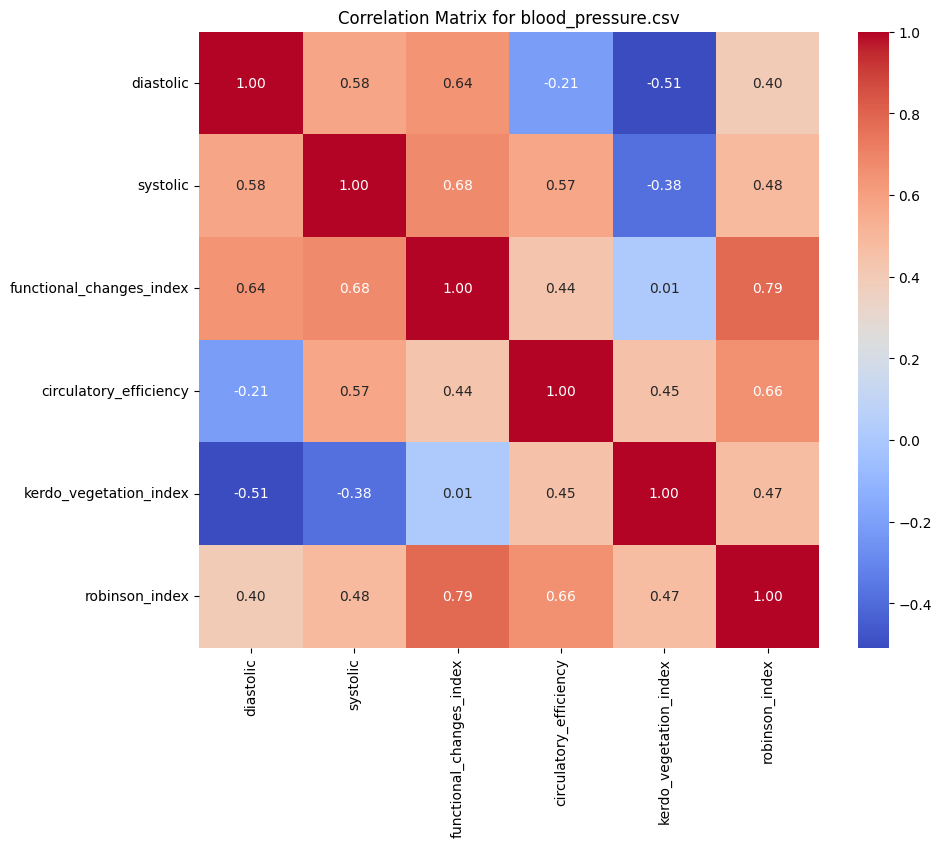

--- heart_rate.csv ---


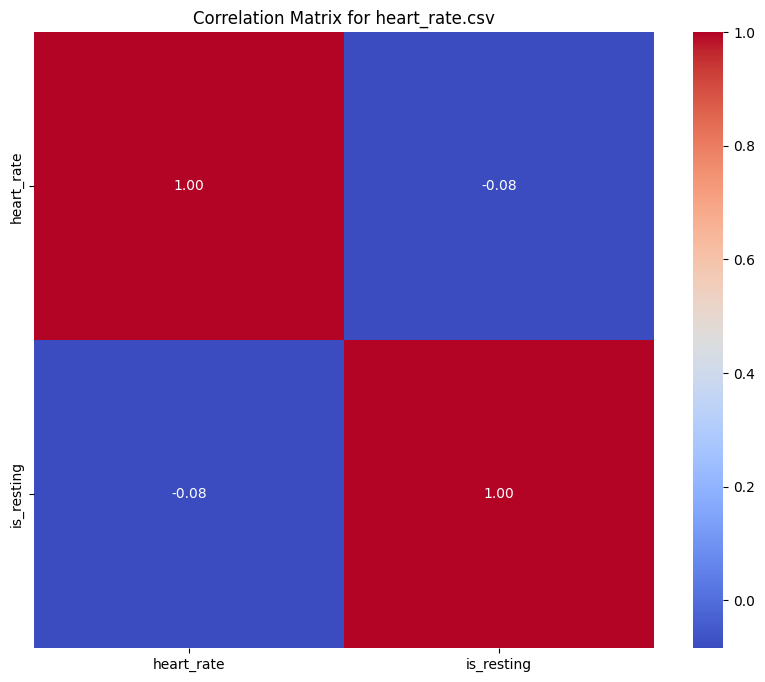

--- hrv_measurements.csv ---


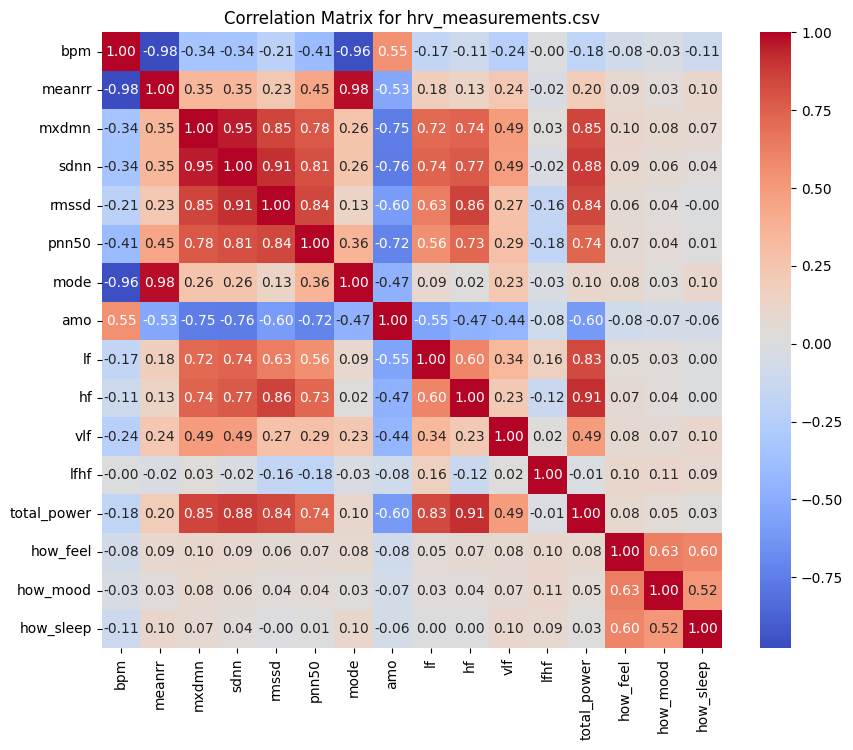

--- participants.csv ---


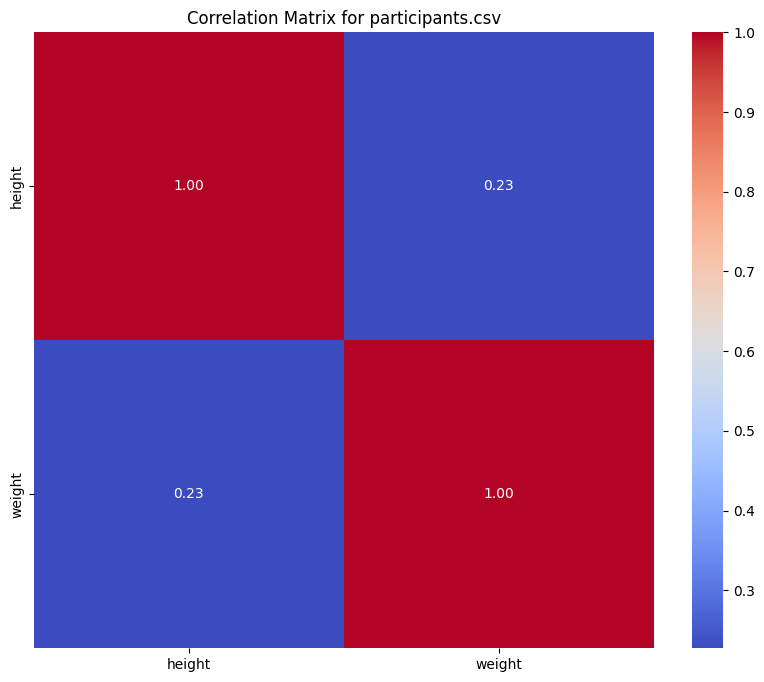

--- scales_description.csv ---
Not enough numerical columns to compute correlation.
--- sleep.csv ---


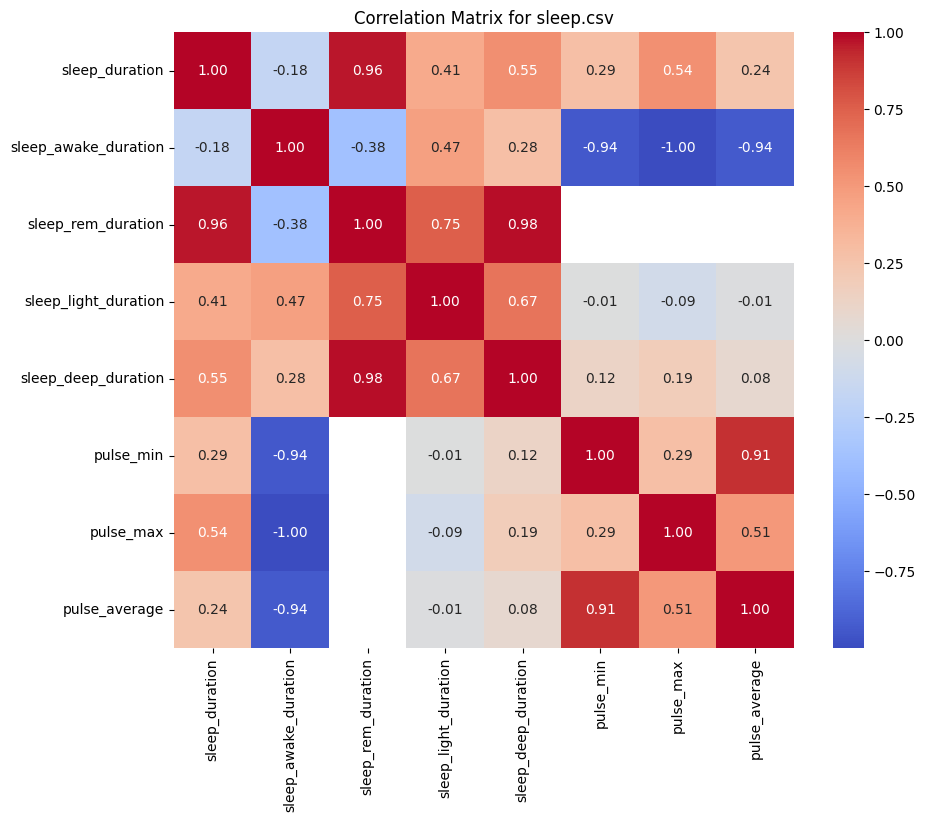

--- surveys.csv ---
Not enough numerical columns to compute correlation.
--- wearables.csv ---


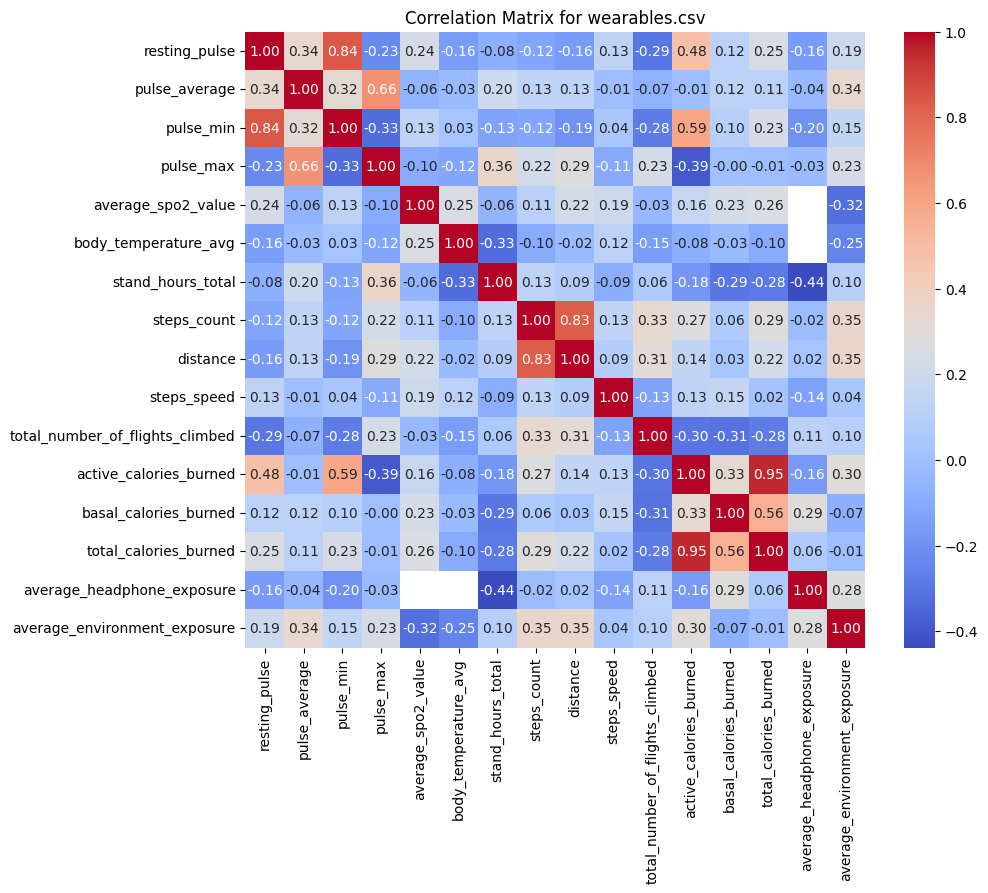

--- weather.csv ---


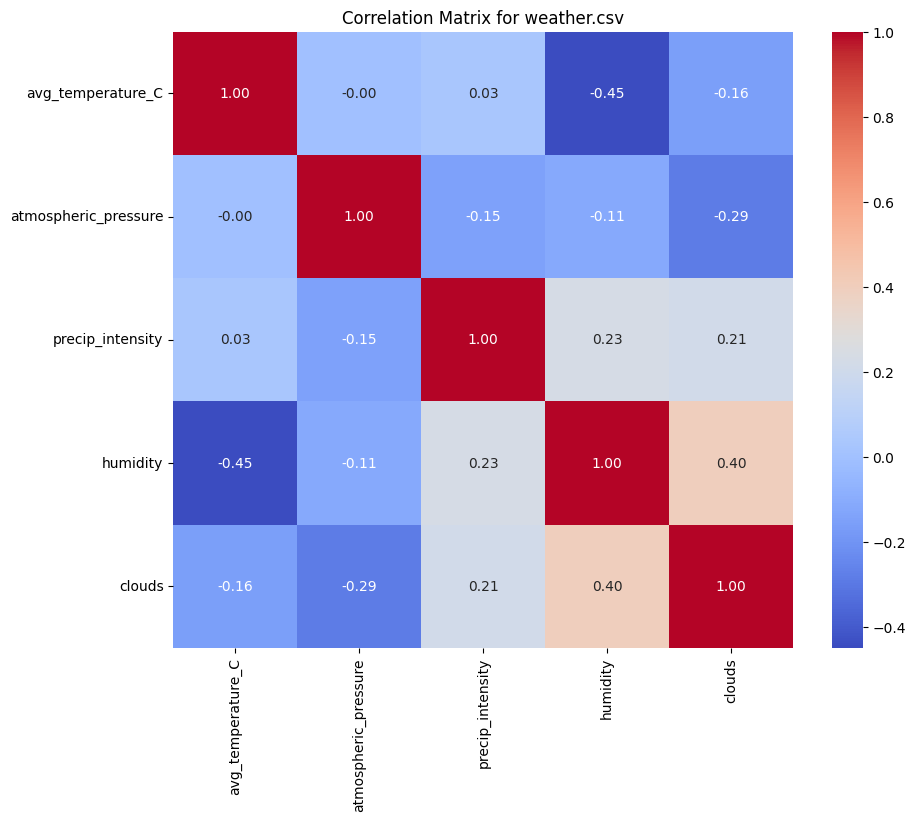

In [44]:
#visualizing the correlation matrix using a heatmap
import seaborn as sns
import matplotlib.pyplot as plt
for filename in os.listdir(data_folder):
    if filename.endswith(".csv"):
        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)
        numeric_cols, categorical_cols = separate_columns(df)
        print(f"--- {filename} ---")
        if len(numeric_cols) > 1:
            correlation_matrix = df[numeric_cols].corr()
            plt.figure(figsize=(10, 8))
            sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
            plt.title(f'Correlation Matrix for {filename}')
            plt.show()
        else:
            print("Not enough numerical columns to compute correlation.")

### the only datasets that seemed to have quite high correlations between two inputs were wearables.csv which had some as high as >0.8 between distance and step_count which makes sense because the number of steps a person takes, directly plays into the distance they would travel.Resting pulse and pulse_min also had high correlation>0.8. If a machine learning engineer were to train a model using the dataset, this feature could be dropped since it would make the model unnecesarily more complex
### surveys.csv,scales_description.csv, were the datasets that didn't have enough numerical data to get a correlation matrix

### From my current exploration, the data has a lot of missing values. It is not consistent with domain knowlegde in terms of heart rate but is consistent in terms of age. There are a few outliers and the data seems to have good symmetry. There are inconsistencies with the data and I plan to keep exploring.